In [138]:

from sklearn.base import ClassifierMixin, BaseEstimator
from sklearn.utils.validation import check_is_fitted
from sklearn.metrics.pairwise import euclidean_distances


from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_checkerboard

import warnings
import numpy as np

import matplotlib.pyplot as plt

X_train, y_train = make_blobs(n_samples=20000, random_state=0, cluster_std=1, centers=10, n_features=150)

X_test, y_test = make_blobs(n_samples=10000, random_state=0, cluster_std=1, centers=10, n_features=150)


In [140]:

class KMeans_self_implemented(BaseEstimator, ClassifierMixin):
    def __init__(self, n_clusters=3, init_method='kmeans++', max_iter=200):
        self.n_clusters = n_clusters
        self.init_method = init_method
        self.max_iter = max_iter
        self._n_features_in = None

    def _init_clusters(self, size):
        return np.random.randint(low=0, high=self.n_clusters, size=size)
    
    def _init_centroids(self, X):
        if self.init_method == 'random':
            print("Doing random initialisation of cluster centroids")
            init_vals = X[np.random.choice(X.shape[0], size=self.n_clusters, replace=False)]
        elif self.init_method == 'kmeans++':
            print("Doing kmeans++ initialisation of cluster centroids")
            # https://theory.stanford.edu/~sergei/papers/kMeansPP-soda.pdf
            centroids = [X[np.random.choice(X.shape[0], size=1, replace=False)]]
            n_clusters_picked = 1

            while n_clusters_picked < self.n_clusters:
                print(n_clusters_picked)
                distances_arr_fast = euclidean_distances(X_train, np.stack(centroids))**2
                minimum_dist_idx = np.argmin(distances_arr_fast, axis=1)

                X_shortest = distances_arr_fast[np.arange(minimum_dist_idx.shape[0]), minimum_dist_idx]

                sample_weight = (X_shortest) / np.sum(X_shortest)

                centroids.append(X[np.random.choice(X.shape[0], size=1, p=sample_weight)])
                n_clusters_picked += 1
            init_vals = np.concatenate(centroids, axis=0)

        init_cluster_centroids = {i: init_vals[i,:] for i in range(init_vals.shape[0])}
        return init_cluster_centroids
    
    def _calculate_cluster_centroid(self, X,y):
        cluster_centroids = {}

        for i in np.unique(y):
            X_gp = X[np.where(y == i)[0]]
            cluster_centroids[i] = (X_gp.mean(axis=0))

        return cluster_centroids
    
    def _d(self, P, cent):
        return np.sqrt(np.sum((P - cent)**2, axis=1))
    
    def _predict_cluster(self, X, cluster_centroids):      
        distances = []
        for _, cluster_centroid in cluster_centroids.items():
            cent=cluster_centroid
            distances.append(self._d(X, cent))

        y_new = np.argmin(np.stack(distances), axis=0)
        
        return y_new
    
    def fit(self, X):
        assert self.n_clusters <= X.shape[0], f"Number of clusters {self.n_clusters} must be less than number of data points {X.shape[0]}"
        if (self.n_clusters == X.shape[0]): warnings.warn(f"The same number of clusters {self.n_clusters} as data points are used {X.shape[0]}")

        y_prev = self._init_clusters(X.shape[0])
        cluster_centroids = self._init_centroids(X)
        y_new = self._predict_cluster(X, cluster_centroids)

        for i in range(self.max_iter):
            print(i, self.max_iter)
            if i == self.max_iter-1: warnings.warn(f"Reached max iterations={self.max_iter}, increase max_iter parameter")
            if (y_prev == y_new).all(): 
                print("stationary clusters, breaking")
                break

            y_prev = y_new
            cluster_centroids = self._calculate_cluster_centroid(X, y_new)
            y_new = self._predict_cluster(X, cluster_centroids)

        self.cluster_centroids = cluster_centroids
        self._n_features_in = X.shape[1]
        self._is_fitted = True
        
    
    def predict(self, X):
        check_is_fitted(self)
        assert X.shape[1] == self._n_features_in, f"Number of features in {self._n_features_in} must be the same as number of prediction features {X.shape[1]}"

        return self._predict_cluster(X, self.cluster_centroids)

    def __sklearn_is_fitted__(self):
        """
        Check fitted status and return a Boolean value.
        """
        return hasattr(self, "_is_fitted") and self._is_fitted

km_SI = KMeans_self_implemented(n_clusters=3, max_iter=300, init_method='random')

km_SI.fit(X_train)
y_preds = km_SI.predict(X_test)


Doing random initialisation of cluster centroids
0 300
1 300
2 300
stationary clusters, breaking


/var/folders/3h/hhvlktwj1rzfznpk5wz5w45w0000gn/T/ipykernel_72092/2467859650.py:6: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_gp[:,0], X_gp[:,1], c=cmap(i))


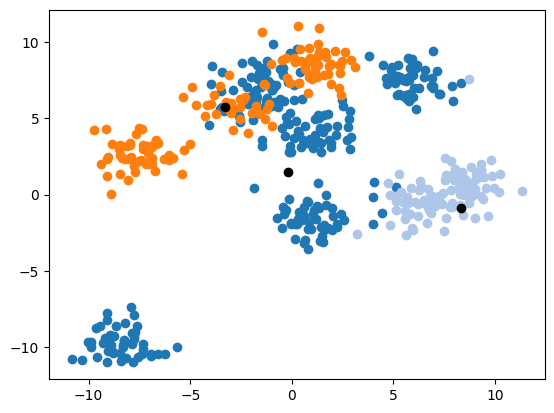

In [92]:

def plot_clusters(X, y, cluster_centroids):
    cmap = plt.get_cmap("tab20")

    for i in np.unique(y):
        X_gp = X[np.where(y == i)[0]]    
        plt.scatter(X_gp[:,0], X_gp[:,1], c=cmap(i))
    
    for i, (cluster_id, cluster_centroid) in enumerate(cluster_centroids.items()):
        plt.scatter(cluster_centroid[0], cluster_centroid[1], c='black')
    plt.show()

plot_clusters(X_test, y_preds, cluster_centroids=km_SI.cluster_centroids)

# Faster euclidean distance calculation




In [ ]:
def d(P, cent):
    return np.sqrt(np.sum((P - cent)**2, axis=1))


In [27]:
%%timeit

distances = []
for centroid in centroids:
    distances.append(d(X_train, centroid)**2)



63.9 ms ± 1.63 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [28]:
%%timeit
euclidean_distances(X_train, centroids)**2

20.8 ms ± 1.91 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


**Provides about 20x improvement**
Improvement grows as n_features grows

# New implementation

In [134]:
centroids_arr = X_train[:1000]
centroids = centroids_arr.tolist()

In [135]:
%%timeit
# Current implementation - SLOW
distances = []
for centroid in centroids:
    distances.append(d(X_train, centroid)**2)

distances_arr = np.stack(distances)
y_new = np.argmin(distances_arr, axis=0)
X_shortest = np.concatenate([dist.reshape(-1,1) for dist in distances], axis=1)[np.arange(y_new.shape[0]), y_new]

sample_weight = (X_shortest) / np.sum(X_shortest)
distances_arr


2.46 s ± 36 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [136]:
%%timeit
# FAST implementation
distances_arr_fast = euclidean_distances(X_train, centroids_arr)**2
minimum_dist_idx = np.argmin(distances_arr_fast, axis=1)

X_shortest = distances_arr_fast[np.arange(y_new.shape[0]), y_new]

sample_weight = (X_shortest) / np.sum(X_shortest)



107 ms ± 4.16 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [ ]:
[]